In [23]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import sys


# Function definitions

### Basic model variables

In [24]:
def potential(h,Hkin,H, nu, hoL, g, mtop ):
    """
    Returns the potential at the field value h

    :param h: field value at which we want to compute the potential
    :param Hkin: Hubble parameter at the onset of kination
    :param H: Hubble parameter at the time we want to compute the potential
    :param nu: associated to the coupling to curvature by xi=(2/3)nu^2
    :param hoL: cutoff scale for the sixth order term
    :param g: sixth order coupling
    :param mtop: top quark pole mass
    """
    Xi = nu*nu * 2 / 3
    fStar = np.sqrt(6 * Xi) * Hkin

    #Coefficients for the running of the quartic self-coupling
    lzero = 7.319652247935477 - 0.09134280450017569*mtop + 0.00029435490652276694*mtop*mtop
    c1 = 0.19832934168591682 - 0.0023418078957534593*mtop + 7.0529784991027215*1e-6*mtop*mtop
    c2 = -0.00014834997676202406 + 7.880425366892111*1e-7*mtop
    c3 = -4.199672393249224 + 0.05306790221079956*mtop - 0.00017089598924459676*mtop*mtop

    #Rescaling to program variables
    H_prog=H/fStar
    h_prog=h/fStar

    #Potential terms
    V2=-3.0 * (h_prog)**2 * Xi * (H_prog)**2
    V4=(lzero + c1*(np.log(fStar**2*((h_prog)**2+(H_prog)**2)))/2.0 +c2*( (np.log(fStar**2*((h_prog)**2+(H_prog)**2)))/2.0)**2+ c3*np.log((np.log(fStar**2*((h_prog)**2+(H_prog)**2)))/2.0))*(h_prog**4)/4
    V6=g**2*(h_prog**6)*(fStar**2)/(8*(hoL)**2)

    return fStar**4*(V2+V4+V6)

def Hubble(Hkin, z, fStar):
    """
    Returns de Hubble parameter at the time z

    :param Hkin: Hubble parameter at the onset of kination
    :param z: Time, in program units, at which we want to cumpute the Hubble parameter
    :param fStar: Rescaling program variable
    """
    return Hkin / (1.0 + 3.0 * Hkin * z / fStar)
def escale_factor(z,nu):
    """
    Returns de scale factor at the time z

    :param z: Time, in program units, at which we want to cumpute the scale factor
    :param nu: Associated to the coupling to curvature by xi=(2/3)nu^2
    """
    return np.sqrt(1+z/nu)


def lamb(h,mtop,H,nu,Hkin):
    """
    Returns de value of the running of the quartic self-coupling lambda at field value h

    :param h: Field value at which we want to compute the quartic self-coupling
    :param mtop: top quark pole mass
    :param H: Hubble parameter for which we want to compute the quartic self-coupling
    :param nu: associated to the coupling to curvature by xi=(2/3)nu^2
    :param Hkin: Hubble parameter at the onset of kination
    """

    Xi = nu*nu * 2 / 3
    fStar = np.sqrt(6 * Xi) * Hkin

    #Coefficients
    lzero = 7.319652247935477 - 0.09134280450017569*mtop + 0.00029435490652276694*mtop*mtop
    c1 = 0.19832934168591682 - 0.0023418078957534593*mtop + 7.0529784991027215*1e-6*mtop*mtop
    c2 = -0.00014834997676202406 + 7.880425366892111*1e-7*mtop
    c3 = -4.199672393249224 + 0.05306790221079956*mtop - 0.00017089598924459676*mtop*mtop

    #Rescaling to program variables    
    H_prog=H/fStar
    h_prog=h/fStar

    l=lzero + c1*(np.log(fStar**2*((h_prog)**2+(H_prog)**2)))/2.0 +c2*( (np.log(fStar**2*((h_prog)**2+(H_prog)**2)))/2.0)**2+ c3*np.log((np.log(fStar**2*((h_prog)**2+(H_prog)**2)))/2.0)
    
    return l

In [25]:
def plot_field_histogram(h5_filenames, group_name, index,hkins,hkins2,nu,colors, fileoutname=0, bins=100):
    """ 
    Plots histograms of field distribution for different input files in the same figure and returns the corresponding time

    :param h5_filenames: array of filenames type .h5. Each of them should contain field snapshots obtained from CosmoLattice and all of them should be obtained for the same times to be consistent.
    :param group_name: Type of field we want to plot: "PHI_S_i" for the real scalar field numer i, "PHI_CS_i"  for the complex scalar field numer i, "PHI_SU2D_i" for the complex SU(2) doublet number i 
    :param index: Time index in the h5 files
    :param hkins: Array of values of the hubble parameters, in scientific notation an 0 decimal places, used for the snapshots in the same order of h5_filenames.
    :param hkins2: Array of values of the hubble parameters, in scientific notation an 1 decimal place, used for the snapshots in the same order of h5_filenames.
    :param nu: Associated to the coupling to curvature by xi=(2/3)nu^2
    :param colors: Array of colors for de different histograms
    :param filoutname: To save the image, write the output filename. Otherwise do not write anything or write 0 (default value).
    :param bins: Number of bins for the histograms. Default value: 100
    """
    plt.figure(figsize=(8, 6))

    #Computing the program rescaling variables for every value of the Hubble parameter at the onset of kination given
    fStars =[]
    Xi = nu*nu * 2 / 3
    
    for hkin in hkins2:
        fStars.append(np.sqrt(6 * Xi) * hkin)

    for hkin in hkins:
        fStars.append(np.sqrt(6 * Xi) * hkin)


    for i,h5_filename in enumerate(h5_filenames):

        with h5py.File(h5_filename, 'r') as f:
            #Reading the corresponding h5 file
            if group_name not in f:
                print(f"The group '{group_name}' is not contained in the file. Available groups: {list(f.keys())}")
                sys.exit(1)

            #Obtaining the snapshots times in order
            group = f[group_name]
            time_keys = list(group.keys())
            sorted_times = sorted(time_keys, key=lambda x: float(x))

            print(f"Available times in {group_name}: {sorted_times}")

            if index < 0 or index >= len(sorted_times):
                print(f"Index out of range. There are {len(sorted_times)} available times.")
                sys.exit(1)

            # Selecting the correct time
            time_key = sorted_times[index]
            time_value = float(time_key)

            print(f"Using index '{time_key}', corresponding to time {time_value})")

            #Saving snapshot data
            data = group[time_key][()]

        #Module, one-dimension array, scaling to physical units, and deleting non-finite values
        data_rescaled = np.abs(data).ravel()*fStars[i]
        data_rescaled = data_rescaled[np.isfinite(data_rescaled)]

        #Plotting histogram
        if i<len(hkins2):
            plt.hist(data_rescaled, bins=bins, density=True, alpha=0.7,label=f"$H_{{kin}}={hkins2[i]:.1e}$ GeV",color=colors[i])
        else:
            plt.hist(data_rescaled, bins=bins, density=True, alpha=0.7,label=f"$H_{{kin}}={hkins[i-len(hkins2)]:.0e}$ GeV",color=colors[i])

    plt.xlabel("$|h|$ [GeV]",fontsize=16)
    plt.ylabel('Probability density',fontsize=16)
    plt.yscale('log')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)
    if fileoutname==0:
        plt.show()
        return time_value
    else:
        plt.savefig(fileoutname)
        plt.show()
        return time_value

In [26]:
def field_percentage(h5_filename,group_name,index,fStar,limit):
    """ 
    Computes the percentage above and below a given limit of an histogram given a field snapshot. Returns: (time, percentage below, percentage above)

    :param h5_filename: filename type .h5. It should contain field snapshots obtained from CosmoLattice.
    :param group_name: Type of field we want to plot: "PHI_S_i" for the real scalar field numer i, "PHI_CS_i"  for the complex scalar field numer i, "PHI_SU2D_i" for the complex SU(2) doublet number i 
    :param index: Time index in the h5 files
    :param fStar: Program rescaling variable corresponding to the input file
    :param limit: Field value acting as the limit we want to compute the percentage above and below.
    """

    #Reading the h5 file
    with h5py.File(h5_filename, 'r') as f:

        if group_name not in f:
            print(f"The group '{group_name}' is not contained in the file. Available groups: {list(f.keys())}")
            sys.exit(1)
        
        #Obtaining the snapshots times in order
        group = f[group_name]
        time_keys = list(group.keys())
        sorted_times = sorted(time_keys, key=lambda x: float(x))

        print(f"Available times in {group_name}: {sorted_times}")


        if index < 0 or index >= len(sorted_times):
            print(f"Index out of range. There are {len(sorted_times)} available times.")
            sys.exit(1)

        # Selecting the correct time
        time_key = sorted_times[index]
        time_value = float(time_key)

        print(f"Usando tiempo '{time_key}' (valor numérico {time_value})")

        #Saving snapshot data
        data = group[time_key][()]

    #Module, one-dimension array, scaling to physical units, and deleting non-finite values
    data_rescaled = np.abs(data).ravel() * fStar
    data_rescaled = data_rescaled[np.isfinite(data_rescaled)]

    total_points = data_rescaled.size
    if total_points == 0:
        raise ValueError("Invalid data")

    #Computing percentages
    below = np.sum(data_rescaled < limit)
    above = np.sum(data_rescaled >= limit)

    pct_below = 100.0 * below / total_points
    pct_above = 100.0 * above / total_points

    print(f"Limit: {limit}")
    print(f"Below the limit: {pct_below:.3f} %")
    print(f"Above the limit: {pct_above:.3f} %")

    return time_value, pct_below, pct_above


In [27]:
def plot_field_histogram_percentages_potential(h5_filename,group_name,index,Hkin,nu,hoL,g,mtop,limit,fileoutname=0,bins=100):
    """ 
    Plots an histogram of field distribution (y-axis on the left) and the corresponding potential in logarithmic scale (y-axis on the right) in the same figure. It computes the percentage of the field below and above a limit and prints it on the legend of the figure. It returns the time value.

    :param h5_filename: filename type .h5. It should contain field snapshots obtained from CosmoLattice.
    :param group_name: Type of field we want to plot: "PHI_S_i" for the real scalar field numer i, "PHI_CS_i"  for the complex scalar field numer i, "PHI_SU2D_i" for the complex SU(2) doublet number i 
    :param index: Time index in the h5 files
    :param Hkin: Hubble parameter at the onset of kination
    :param nu: Associated to the coupling to curvature by xi=(2/3)nu^2
    :param hoL: cutoff scale for the sixth order term
    :param g: sixth order coupling
    :param mtop: top quark pole mass
    :param limit: Field value acting as the limit we want to compute the percentage above and below.
    :param filoutname: To save the image, write the output filename. Otherwise do not write anything or write 0 (default value).
    :param bins: Number of bins for the histograms. Default value: 100

    """
    plt.figure(figsize=(8, 6))
    Xi = nu*nu * 2 / 3
    fStar = np.sqrt(6 * Xi) * Hkin

    #Reading the h5 file
    with h5py.File(h5_filename, 'r') as f:

        if group_name not in f:
            print(f"The group '{group_name}' is not contained in the file. Available groups: {list(f.keys())}")
            sys.exit(1)

        #Obtaining the snapshots times in order
        group = f[group_name]
        time_keys = list(group.keys())
        sorted_times = sorted(time_keys, key=lambda x: float(x))

        print(f"Available times in {group_name}: {sorted_times}")

        if index < 0 or index >= len(sorted_times):
            print(f"Index out of range. There are {len(sorted_times)} available times.")
            sys.exit(1)

        # Selecting the correct time
        time_key = sorted_times[index]
        time_value = float(time_key)

        print(f"Usando tiempo '{time_key}' (valor numérico {time_value})")

        #Saving snapshot data
        data = group[time_key][()]

    #Module, one-dimension array, scaling to physical units, and deleting non-finite values
    data_rescaled = np.abs(data).ravel() * fStar
    data_rescaled = data_rescaled[np.isfinite(data_rescaled)]

    #Computing percentages using the function field_percentage
    t, pct_below, pct_above = field_percentage(h5_filename,group_name,index,fStar,limit,)

    #Histogram plot in the first axis
    ax1 = plt.gca()
    n, bins_hist, patches = ax1.hist(data_rescaled,bins=bins,density=True,alpha=0.7,label="Distribución",color="#5DB3F9")

    ax1.set_xlabel(r"$|h|$ [GeV]",fontsize=16)
    ax1.set_ylabel("Probability density",fontsize=16)
    ax1.grid(True)    
    #ax1.set_yscale('log')

    #Potential plot in the second axis
    h_grid = np.linspace(data_rescaled.min(), data_rescaled.max(), 2000)
    Ht = Hubble(Hkin,time_value,fStar)
    V = potential(h_grid,Hkin,Ht,nu,hoL,g,mtop)

    Vlog = np.sign(V) * np.log10(np.abs(V) + 1e-300)

    ax2 = ax1.twinx()
    ax2.plot(h_grid,Vlog,'r-',lw=2,label=r'$\mathrm{sign}(V)\log_{10}|V|$',color="#C407F4")
    ax2.set_ylabel(r'$\mathrm{sign}(V)\log_{10}|V|$', fontsize=16)

    ax1.tick_params(axis='both', labelsize=14)
    ax2.tick_params(axis='both', labelsize=14)

    #Legend
    factor, exponent = f"{limit:.1e}".split("e")
    exponent = int(exponent)
    if factor=="1.0":
        limite_tex = rf"10^{{{exponent}}}"
    else:
        limite_tex = rf"{factor}·10^{{{exponent}}}"

    legend_text = (f"$|h| < {limite_tex}$ : {pct_below:.4f} %\n" f"$|h| \geq {limite_tex}$ : {pct_above:.4f} %")

    custom_lines = [Line2D([0], [0], color="#5DB3F9", lw=6, alpha=0.7),Line2D([0], [0], color="#C407F4", lw=2)]

    ax2.legend(custom_lines,[legend_text,"$V(h)$"],loc="center",bbox_to_anchor=(0.4, 0.5),fontsize = 12)

    #Saving figure
    if fileoutname == 0:
        plt.show()
    else:
        plt.savefig(fileoutname, bbox_inches="tight")
        plt.show()

    return time_value


<>:87: SyntaxWarning: invalid escape sequence '\g'
<>:87: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_1185/2867005507.py:87: SyntaxWarning: invalid escape sequence '\g'
  legend_text = (f"$|h| < {limite_tex}$ : {pct_below:.4f} %\n" f"$|h| \geq {limite_tex}$ : {pct_above:.4f} %")


### Spectrum

In [28]:
def load_spectrum(filename, comment = '#'):
    """  
    Reads a file containing spectra from cosmolattice and returns the number of bins and number of spectra it contains
    :param filename: Name of the file containing the spectra. It should be spectra_scalar_i.txt from cosmolattice for the real scalar field number i (and analogous for other kinds of fields)
    :param comment: The symbol comented lines in the input file start with. Default value #.
    """

    # Opening the file and counting bins per spectrum
    file = open(filename)
    nBins = 0
    line = file.readline()

    while line != "\n":
        if(line[0] != comment):
            nBins +=1
        line = file.readline()
    file.close()

    #Reading data
    spectra = np.loadtxt(filename, comments=comment)

    #Number of spectra (or times)
    nSpectra = len(spectra) / nBins

    return spectra, int(nBins), int(nSpectra)


def plot_spectrum(spectra, column, nBins, nSpectra, colormap = 'plasma'):
    """
    Plots the spectrum for the column indicated and for every time
    :param spectra: Contains an array of matrices, one for each time, where the first column should contain the momenta. If obtained from cosmolattice, the second usually contains the power spectrum of the field, the third contains the power spectrum of its derivative and the forth one the occupation number.
    :param column: The number of the column we want to plot the spectrum (If the file is obtained from cosmolattice, 1 for power spectrum of the field, 2 for the power spectrum of its derivative and 3 for the occupation number.
    :param nBins: Number of bins for the spectrum. It has to be the number of lines each matrix of the file has.
    :param nSpectra: Number of spectra to be plotted. It is the number of times CosmoLattice has recorded the spectra and has to be the number of matrices contained in the file.
    :param colormap: Colors for the plot. Each time will be plotted in a different color. Default value 'plasma'
    """
    colors = plt.get_cmap(colormap)
    for i in range(nSpectra):
        plt.plot(spectra[i*nBins:(i+1)*nBins,0], spectra[i*nBins:(i+1)*nBins,column], color=colors(i/nSpectra))
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('$\\tilde k$')

### Energy densities

In [29]:
def energy(file, index):
    """ 
    Given a file which contains CosmoLattice average energies and an index o time, returns the average total energy density at that time obtained from the file.
    :param file: Filename of the file containing the energies. It should be an average_energies.txt obtained from CosmoLattice
    :param index: Number indexing in the file the time at which the energy is wanted.
    """
    times = []
    energies = []

    with open(file, "r") as f:
        for line in f:
            parts = line.split()
            if len(parts) < 2:
                continue

            try:
                t = float(parts[0])
                e_total = float(parts[-1])
            except ValueError:
                continue

            if t == t and e_total == e_total:
                times.append(t)
                energies.append(e_total)

    if index < 0 or index >= len(energies):
        print(f"Index out of range (0-{len(energies)-1})")
        sys.exit(1)

    return times[index], energies[index]

def EK(file, index):
    """ 
    Given a file which contains CosmoLattice average energies and an index o time, returns the average kinetic energy density at that time obtained from the file.
    :param file: File containing the energies. It should be an average_energies.txt obtained from CosmoLattice
    :param index: Number indexing in the file the time at which the energy is wanted.
    """
    times = []
    energies = []

    with open(file, "r") as f:
        for line in f:
            parts = line.split()
            if len(parts) < 2:
                continue

            try:
                t = float(parts[0])
                ek = float(parts[1])
            except ValueError:
                continue

            if t == t and ek == ek:
                times.append(t)
                energies.append(ek)

    if index < 0 or index >= len(energies):
        print(f"Index out of range (0-{len(energies)-1})")
        sys.exit(1)

    return times[index], energies[index]

def EG(file, index):
    """ 
    Given a file which contains CosmoLattice average energies and an index o time, returns the average gradient energy density at that time obtained from the file.
    :param file: File containing the energies. It should be an average_energies.txt obtained from CosmoLattice
    :param index: Number indexing in the file the time at which the energy is wanted.
    """
    times = []
    energies = []

    with open(file, "r") as f:
        for line in f:
            parts = line.split()
            if len(parts) < 2:
                continue

            try:
                t = float(parts[0])
                eg = float(parts[2])
            except ValueError:
                continue

            if t == t and eg == eg:
                times.append(t)
                energies.append(eg)

    if index < 0 or index >= len(energies):
        print(f"Index out of range (0-{len(energies)-1})")
        sys.exit(1)
    return times[index], energies[index]


def EV(file, index):
    """ 
    Given a file which contains CosmoLattice average energies and an index o time, returns the average potential energy density (without curvature term) at that time obtained from the file.
    :param file: File containing the energies. It should be an average_energies.txt obtained from CosmoLattice
    :param index: Number indexing in the file the time at which the energy is wanted.
    """
    times = []
    energies = []

    with open(file, "r") as f:
        for line in f:
            parts = line.split()
            if len(parts) < 2:
                continue

            try:
                t = float(parts[0])
                ev = float(parts[4])+float(parts[5])
            except ValueError:
                continue

            if t == t and ev == ev:
                times.append(t)
                energies.append(ev)

    if index < 0 or index >= len(energies):
        print(f"Index out of range (0-{len(energies)-1})")
        sys.exit(1)
    return times[index], energies[index]


def hubble(file, index):
    """ 
    Given a file which contains CosmoLattice average scale factor and Hubble parameter and an index or time, returns the average Hubble parameter at that time obtained from the file.
    :param file: File containing the scale factor, its derivative and the Hubble parameter. It should be an average_scale_factor.txt obtained from CosmoLattice
    :param index: Number indexing in the file the time at which the energy is wanted.
    """
    times = []
    hubbles = []

    with open(file, "r") as f:
        for line in f:
            parts = line.split()
            if len(parts) < 2:
                continue

            try:
                t = float(parts[0])
                h = float(parts[3])
            except ValueError:
                continue

            if t == t and h == h:
                times.append(t)
                hubbles.append(h)

    if index < 0 or index >= len(hubbles):
        print(f"Index out of range (0-{len(hubbles)-1})")
        sys.exit(1)
    return times[index], hubbles[index]


def field2(file,index):
    """ 
    Given a file which contains CosmoLattice average fields and an index o time, returns the average field value at that time obtained from the file.
    :param file: File containing the average fields obtained from CosmoLattice
    :param index: Number indexing in the file the time at which the field value is wanted.
    """
    times = []
    fields2 = []

    with open(file, "r") as f:
        for line in f:
            parts = line.split()
            if len(parts) < 2:
                continue

            try:
                t = float(parts[0])
                f = float(parts[3])
            except ValueError:
                continue

            if t == t and f == f:
                times.append(t)
                fields2.append(f)

    if index < 0 or index >= len(fields2):
        print(f"Index out of range (0-{len(fields2)-1})")
        sys.exit(1)

    return times[index], fields2[index]


In [30]:
def energy_br_fit(h,Hkin, nu,mtop):
    """ 
    Returns the energy density at back reaction time computed through a fitting formula
    :param h: Field value at back-reaction time
    :param Hkin: Hubble parameter at the onset of kination
    :param nu: Associated to the coupling to curvature by xi=(2/3)nu^2
    :param mtop: top quark pole mass
    """
    Xi = nu*nu * 2 / 3

    fStar = np.sqrt(6 * Xi) * Hkin

    lzero = 7.319652247935477 - 0.09134280450017569*mtop + 0.00029435490652276694*mtop*mtop
    c1 = 0.19832934168591682 - 0.0023418078957534593*mtop + 7.0529784991027215*1e-6*mtop*mtop
    c2 = -0.00014834997676202406 + 7.880425366892111*1e-7*mtop
    c3 = -4.199672393249224 + 0.05306790221079956*mtop - 0.00017089598924459676*mtop*mtop

    Hkin_prog=Hkin/fStar
    h_prog=h/fStar

    l = lzero + c1*(np.log(fStar**2*((h_prog)**2+(Hkin_prog)**2)))/2.0 +c2*( (np.log(fStar**2*((h_prog)**2+(Hkin_prog)**2)))/2.0)**2+ c3*np.log((np.log(fStar**2*((h_prog)**2+(Hkin_prog)**2)))/2.0)
    n=-np.log(l)
    beta1=-7.031969405356514 - 0.5625162459577862*n
    beta2=-0.05726296471140456 - 0.036344004289454265*n
    beta3=7.153524652006633 + 1.1032724722012484*n

    return 16*Hkin**4*np.exp(beta1+beta2*nu+beta3*np.log(nu))

In [31]:
def energy_rad_fit(Hkin,nu,mtop,dir,index):
    """
    Returns the energy when the field starts to behave as radiation computed through a fitting formula valid only for g=0
    :param Hkin: Hubble parameter at the onset of kination
    :param nu: Associated to the coupling to curvature by xi=(2/3)nu^2
    :param mtop: top quark pole mass
    :param dir: Directory where the CosmoLattice outputs are located
    :param index: Number indexing the time in the files at dir at which we want the energy calculated
    """
    Xi = nu*nu * 2 / 3
    
    fStar = np.sqrt(6 * Xi) * Hkin

    lzero = 7.319652247935477 - 0.09134280450017569*mtop + 0.00029435490652276694*mtop*mtop
    c1 = 0.19832934168591682 - 0.0023418078957534593*mtop + 7.0529784991027215*1e-6*mtop*mtop
    c2 = -0.00014834997676202406 + 7.880425366892111*1e-7*mtop
    c3 = -4.199672393249224 + 0.05306790221079956*mtop - 0.00017089598924459676*mtop*mtop

    t,h2=field2(dir+"average_scalar_0.txt",index)
    H = Hubble(Hkin,t,fStar)

    h_prog=np.sqrt(h2)

    l = lzero + c1*(np.log(fStar**2*((h_prog)**2+(H)**2)))/2.0 +c2*( (np.log(fStar**2*((h_prog)**2+(H)**2)))/2.0)**2+ c3*np.log((np.log(fStar**2*((h_prog)**2+(H)**2)))/2.0)
    n=-np.log(l)
    delta1=-11.2 - 0.06*n
    delta2=-0.04 - 0.03*n
    delta3=5.62 + 0.87*n
    rho= 16*Hkin**4*np.exp(delta1+delta2*nu+delta3*np.log(nu))


    return rho

In [32]:
def heating_temperature(rhorad,Hkin,nu):
    """
    Returns the heating temperature given the energy when the field starts to behave as radiation
    :param rhorad: Energy density of the field when it starts to behave as radiation
    :param Hkin: Hubble parameter at the onset of kination
    :param nu: Associated to the coupling to curvature by xi=(2/3)nu^2
    """
    Xi = nu*nu * 2 / 3
    fStar = np.sqrt(6 * Xi) * Hkin

    Mp=1.22e19/np.sqrt(8*np.pi)
    arad=escale_factor(Hkin, t,fStar)
    rhorh = rhorad**3*arad**(12)/(9*Mp**4*Hkin**4)
    Trh=(30*rhorh/(np.pi**2*106.75))**(1/4)
    return Trh
def nefolds(rhorad,Hkin,nu):
    """
    Returns the number of e-folds kination lasts given the energy when the field starts to behave as radiation
    :param rhorad: Energy density of the field when it starts to behave as radiation
    :param Hkin: Hubble parameter at the onset of kination
    :param nu: Associated to the coupling to curvature by xi=(2/3)nu^2
    """
    Xi = nu*nu * 2 / 3
    fStar = np.sqrt(6 * Xi) * Hkin

    Mp=1.22e19/np.sqrt(8*np.pi)
    arad=escale_factor(Hkin, t,fStar)
    arh = np.sqrt(3*Mp**2*Hkin**2/(rhorad*arad**4))
    Nefolds = np.log(arh)
    return Nefolds

# Pontential

<>:20: SyntaxWarning: invalid escape sequence '\,'
<>:20: SyntaxWarning: invalid escape sequence '\,'
<>:20: SyntaxWarning: invalid escape sequence '\,'
<>:20: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_1185/3296030743.py:20: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(h, Vlog[i],color=colors[i],label=f"$m_t={mtops[i]},\,g={gs[i]},\,H_{{kin}}={Hkins[i]:.1e}$",zorder=zorders[i])
/tmp/ipykernel_1185/3296030743.py:20: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(h, Vlog[i],color=colors[i],label=f"$m_t={mtops[i]},\,g={gs[i]},\,H_{{kin}}={Hkins[i]:.1e}$",zorder=zorders[i])


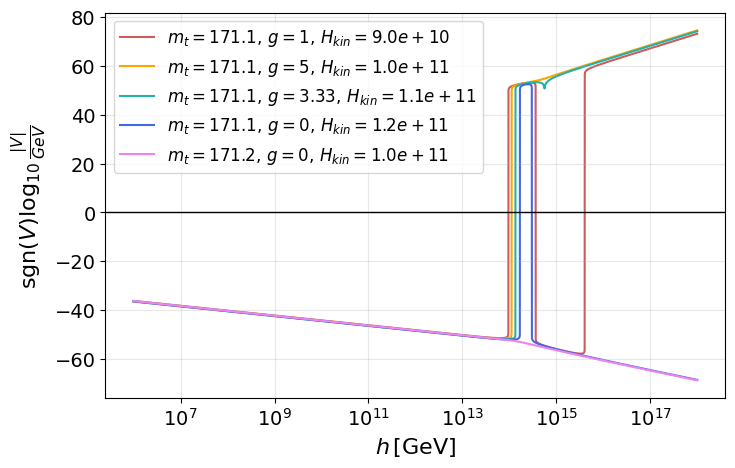

In [33]:
hoL=1e17
nu=10
Hkins = [9e10,1e11,1.1e11,1.2e11,1e11]
mtops = [171.1,171.1,171.1,171.1,171.2]
gs=[1,5,3.33,0,0]

h = np.logspace(6, 18, 20000)
plt.figure(figsize=(8,5))

Xi = nu*nu * 2 / 3
fStars = []
Vh = []
Vlog = []
colors = ["indianred","orange","lightseagreen","royalblue","violet"]
zorders = [1,1,1,1,20]
for i in range(5):
    fStars.append(np.sqrt(6 * Xi) * Hkins[i])
    Vh.append(potential(h,Hkins[i],Hkins[i], nu, hoL, gs[i], mtops[i]))
    Vlog.append(np.sign(Vh[i]) * np.log10((np.abs(Vh[i])+1e-30)))
    plt.plot(h, Vlog[i],color=colors[i],label=f"$m_t={mtops[i]},\,g={gs[i]},\,H_{{kin}}={Hkins[i]:.1e}$",zorder=zorders[i])

plt.xscale('log')
plt.xlabel(r"$h\,$[GeV]", fontsize=16)
plt.ylabel(r"$\mathrm{sgn}(V)\log_{10}\frac{|V|}{GeV}$", fontsize=16)
plt.grid(True, alpha=0.3)
plt.axhline(0, color="black", linewidth=1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


plt.legend(loc='upper left',fontsize=12)
plt.show()


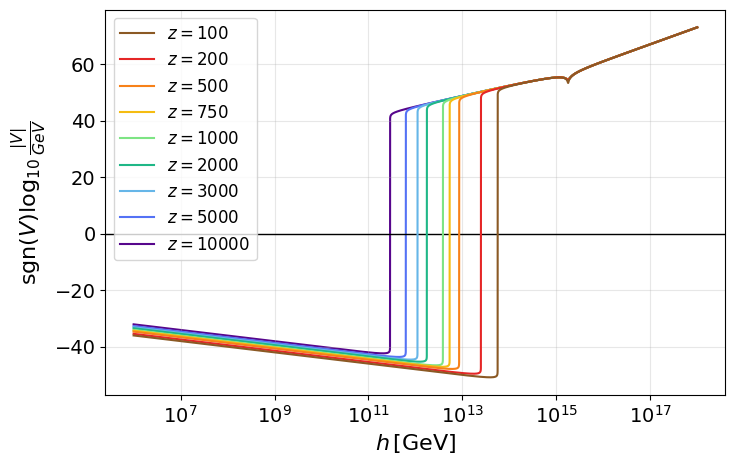

In [34]:
hoL=1e17
nu=10
Hkin=1.2e12
mtop = 171.036
g=1
Xi = nu*nu * 2 / 3
fStar = np.sqrt(6 * Xi) * Hkin
h = np.logspace(6, 18, 20000)
plt.figure(figsize=(8,5))

colors=["#8B5924","#E52626","#F78119","#F5BC12","#7DE484","#1FB787","#66B6E8","#5472F5","#57068C"]

zs = [100,200,500,750,1000,2000,3000,5000,10000]
zorders = [50,40,30,20,10,5,3,2,1]

Vlog = []

for i in range(len(zs)):
    Hz=Hubble(Hkin,zs[i],fStar)
    Vh=potential(h,Hkin,Hz,nu,hoL,g,mtop)
    Vlog=np.sign(Vh) * np.log10((np.abs(Vh)+1e-30))
    plt.plot(h, Vlog,color=colors[i],label=f"$z={zs[i]}$",zorder=zorders[i])


plt.xscale('log')
plt.xlabel(r"$h\,$[GeV]", fontsize=16)
plt.ylabel(r"$\mathrm{sgn}(V)\log_{10}\frac{|V|}{GeV}$", fontsize=16)
plt.grid(True, alpha=0.3)
plt.axhline(0, color="black", linewidth=1)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


plt.legend(loc='upper left',fontsize=12)
plt.show()


# Energy evolution

<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1185/2270743623.py:22: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\langle \\rho\\rangle a^4$")


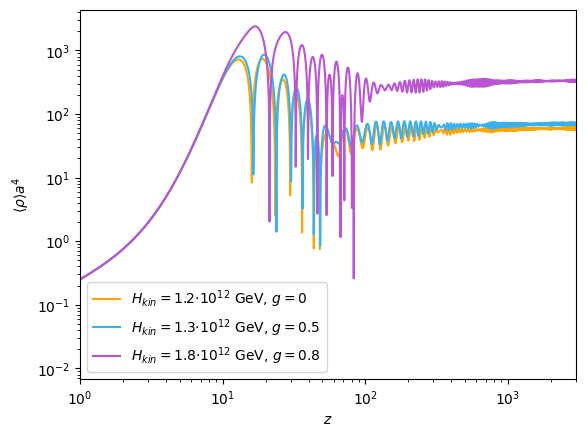

In [35]:
#Total energy density for different simulations
dirs = ["./simulaciones_largas/mtop171.02/Hkin1.2e12_g0/g0/","./simulaciones_largas/mtop171.02/Hkin1.3e12_g0.5/g0.5/","./simulaciones_largas/mtop171.02/Hkin1.8e12_g0.8/"]



colors = ["orange", "#39B1F1", "mediumorchid"]
labels = ["$K$", "$G$", "$V$", "$|I|$", "$|\\rho_{tot}|$"]
labels = [r"$H_{kin}=1.2·10^{12}$ GeV, $g=0$",r"$H_{kin}=1.3·10^{12}$ GeV, $g=0.5$",r"$H_{kin}=1.8·10^{12}$ GeV, $g=0.8$"]

plt.figure(0)

for i in range(len(dirs)):
    dir = dirs[i]
    aDat = np.loadtxt(dir + "average_scale_factor.txt")
    enDat = np.loadtxt(dir + "average_energies.txt")
    plt.plot(enDat[:,0], aDat[:,1]**4 * np.abs(enDat[:,7]), color = colors[i], label=labels[i])

plt.yscale('log')
plt.xscale('log')
plt.xlabel("$z$")
plt.xlim(1,3000)
plt.ylabel("$\langle \\rho\\rangle a^4$")
plt.legend()

<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1185/2222883399.py:20: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\langle \\rho\\rangle a^4$")


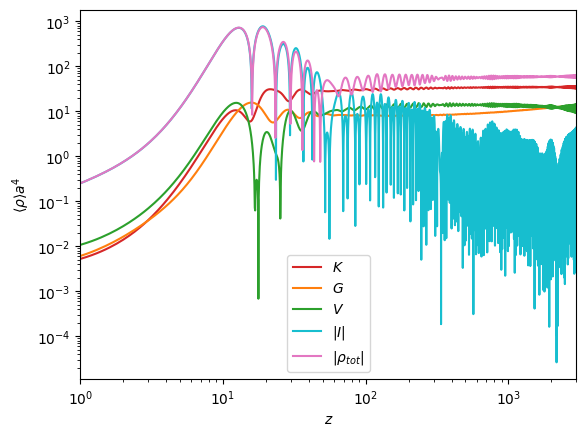

In [36]:
#Components of the energy density
dir = "./simulaciones_largas/mtop171.02/Hkin1.2e12_g0/g0/"
aDat = np.loadtxt(dir + "average_scale_factor.txt")
enDat = np.loadtxt(dir + "average_energies.txt")

colors = ["tab:red", "tab:orange", "tab:green", "tab:cyan", "tab:pink"]
labels = ["$K$", "$G$", "$V$", "$|I|$", "$|\\rho_{tot}|$"]

plt.figure(0)
plt.plot(enDat[:,0], aDat[:,1]**4 * np.abs(enDat[:,1]), color = colors[0], label=labels[0])
plt.plot(enDat[:,0], aDat[:,1]**4 * np.abs(enDat[:,2]), color = colors[1], label=labels[1])
plt.plot(enDat[:,0], aDat[:,1]**4 * np.abs((enDat[:,4]+enDat[:,5])), color = colors[2], label=labels[2])
plt.plot(enDat[:,0], aDat[:,1]**4 * np.abs(enDat[:,3]+enDat[:,6]), color = colors[3], label=labels[3])
plt.plot(enDat[:,0], aDat[:,1]**4 * np.abs(enDat[:,7]), color = colors[4], label=labels[4])

plt.yscale('log')
plt.xscale('log')
plt.xlabel("$z$")
plt.xlim(1,3000)
plt.ylabel("$\langle \\rho\\rangle a^4$")
plt.legend()

# Spectrum

<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1185/3472657142.py:6: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0}$')
/tmp/ipykernel_1185/3472657142.py:11: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
/tmp/ipykernel_1185/3472657142.py:16: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\\tilde n_{\\tilde\phi_0}$')


(10.0, 100000.0)

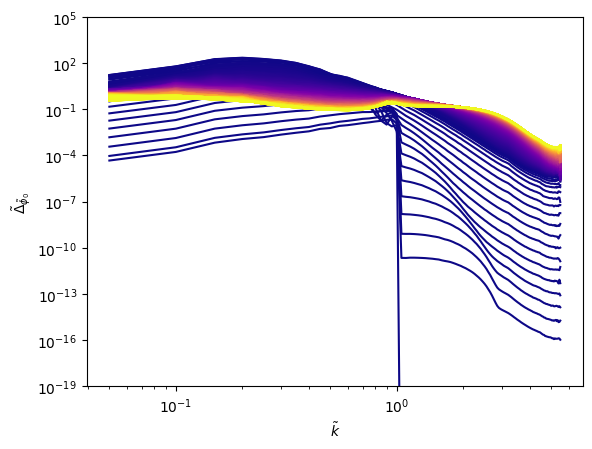

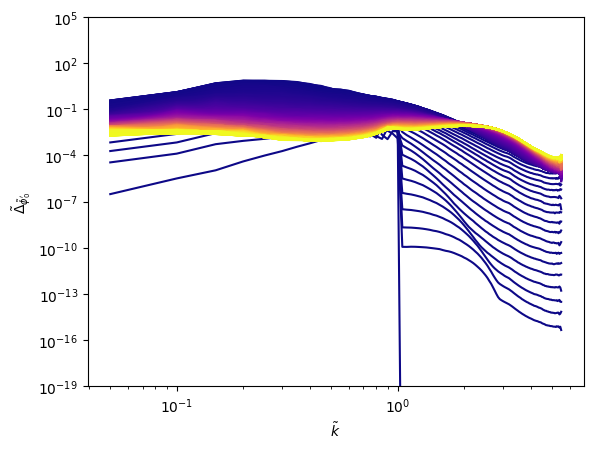

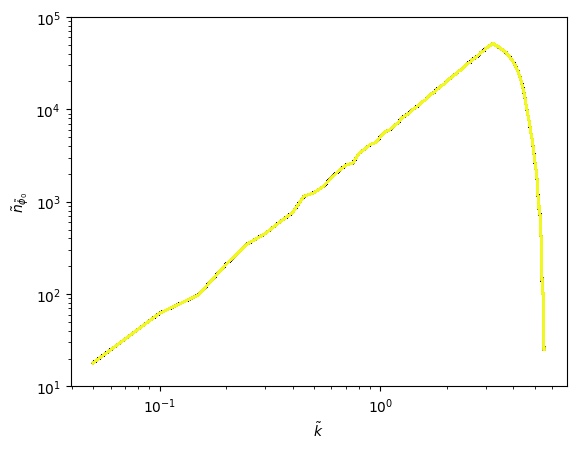

In [37]:
#Plotting spectra
spectra, nBins, nSpectra = load_spectrum(dir + "spectra_scalar_0.txt")

plt.figure(0)
plot_spectrum(spectra, 1,  nBins, nSpectra)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0}$')
plt.ylim([1e-19,1e5])

plt.figure(1)
plot_spectrum(spectra, 2,  nBins, nSpectra)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.ylim([1e-19,1e5])

plt.figure(2)
plot_spectrum(spectra, 3,  nBins, nSpectra)
plt.ylabel('$\\tilde n_{\\tilde\phi_0}$')
plt.ylim([1e1,1e5])

# Hubble parameter

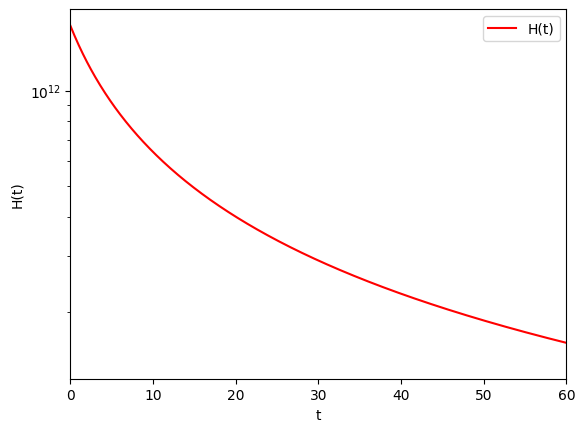

2.909e+11


In [38]:

dir="./escaneo_energias/mtop171.04/Hkin1.6e12/g1.3/"
aDat = np.loadtxt(dir + "average_scale_factor.txt")

z = aDat[:, 0]      
a = aDat[:, 1]  
adot = aDat[:, 2]      
H = aDat[:, 3]    

Hkin=1.6e12
nu=10
Xi = nu*nu * 2 / 3
fStar = np.sqrt(6 * Xi) * Hkin

plt.figure()

plt.plot(z, H*fStar, label="H(t)", color="red")


plt.xlabel("t")
plt.ylabel("H(t)")
plt.yscale("log")  
plt.xlim(0,60)


plt.legend()

plt.show()
print(f"{fStar*H[300]:.3e}")


# Reheating temperature

In [39]:
dirs=["./simulaciones_largas/mtop171.02/Hkin1.2e12_g0/g0/","./simulaciones_largas/mtop171.02/Hkin1.3e12_g0.5/g0.5/","./simulaciones_largas/mtop171.02/Hkin1.8e12_g0.8/"]
Hkins = [1.2e12,1.3e12,1.8e12]
nu=10
Xi = nu*nu * 2 / 3
mtop =171.02
fStars = []
for Hkin in Hkins:
    fStars.append(np.sqrt(6 * Xi) * Hkin)

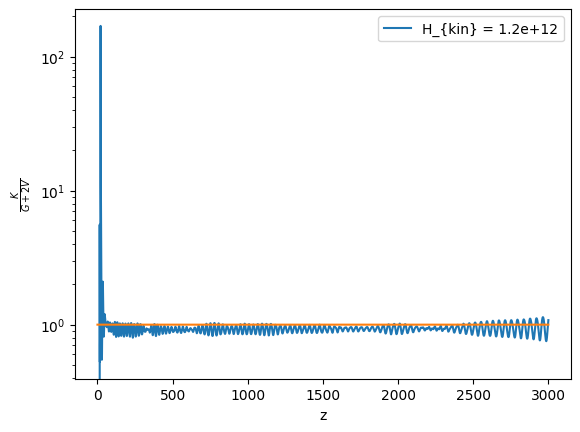

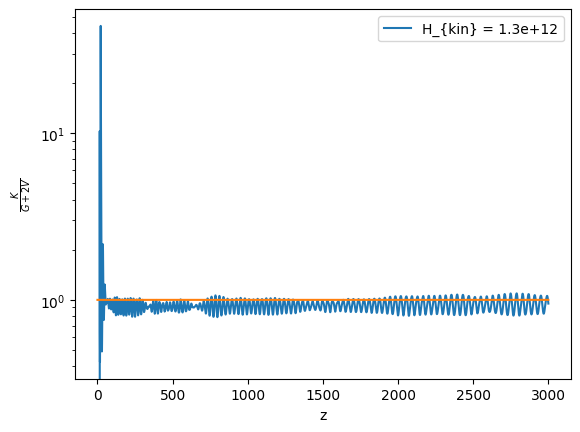

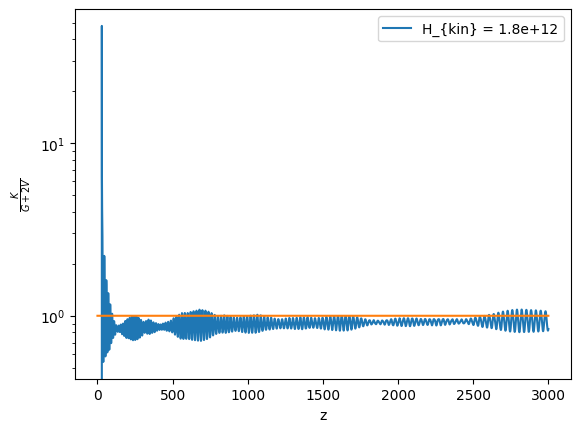

In [40]:
# Establishing radiation time i.e. the time when we consider that the field starts to behave as radiation
quotients=[[],[],[]]

for k in range(len(dirs)):
    enDat = np.loadtxt(dirs[k] + "average_energies.txt")
    times=enDat[:,0]
    K=enDat[:,1]
    G=enDat[:,2]
    V=enDat[:,4]+enDat[:,5]
    i=len(K)-1
    for j in range(i+1):
        quotients[k].append(K[j]/(G[j]+2*V[j]))

    plt.figure()
    plt.plot(times, quotients[k], label=rf"H_{{kin}} = {Hkins[k]:.1e}")
    plt.plot(times,[1]*len(times))

    plt.xlabel("z")
    plt.ylabel(r"$\frac{K}{G+2V}$")
    plt.yscale("log")

    plt.legend()
    plt.show()


In [41]:
# Averaging quotient in 5 oscillations
eps=1e-3
ranges = [1100,500,800]
zfin = [29574,29999,29831]
for k in range(len(dirs)):
    osc = []
    for j in range(ranges[k]):
        if np.abs(quotients[k][zfin[k]-j]-1)<eps:
            osc.append(zfin[k]-j)
    print(osc)
    average=0
    for j in range(zfin[k]-osc[-1]):
        average=average+quotients[k][zfin[k]-j]/(zfin[k]-osc[-1])
    print(average)

[29549, 29128, 28879, 28709]
0.950122150463506
[29972, 29844, 29843, 29564]
0.9428106278773531
[29757, 29540, 29435, 29116]
0.9500744829433125


In [42]:
# Computing radiation energy density: the energy of the field when we consider it starts to behave at radiation

# Radiation time index in simulations
indexes = [29574,29650,29831]

rhorad_sim = []
rhorad_fit = []

for k in range (len(dirs)):

    # Radiation energy from simulations
    z, rho_prog = energy(dirs[k]+"average_energies.txt", indexes[k])
    rhorad_sim.append(rho_prog*fStars[k]**4)

    # Radiation energy from fitting formula (only precise for g=0)
    rhorad_fit.append(energy_rad_fit(Hkins[k],nu,mtop,dirs[k],indexes[k]))

    print(f"Index {indexes[k]} → time = {z}")
    print(f"Hkin:{Hkins[k]:.1e} → Simulations radiation energy density: ",f"{rhorad_sim[k]:.3e}")
    print(f"Hkin:{Hkins[k]:.1e} → Fitting radiation energy density: ",f"{rhorad_fit[k]:.3e}")



Index 29574 → time = 2957.40000001813
Hkin:1.2e+12 → Simulations radiation energy density:  5.518e+51
Hkin:1.2e+12 → Fitting radiation energy density:  4.710e+54
Index 29650 → time = 2965.0000000183
Hkin:1.3e+12 → Simulations radiation energy density:  9.693e+51
Hkin:1.3e+12 → Fitting radiation energy density:  6.135e+54
Index 29831 → time = 2983.10000001869
Hkin:1.8e+12 → Simulations radiation energy density:  1.658e+53
Hkin:1.8e+12 → Fitting radiation energy density:  1.820e+55


In [43]:
# Computing reheating temperature and number of efolds
Mp=1.22e19/np.sqrt(8*np.pi)
Trh = []
Nefolds = []

for k in range(len(dirs)):
    #arad=escale_factor(Hkins[k], z,fStars[k])
    arad = escala(z,10)
    rhorh = rhorad_sim[k]**3*arad**(12)/(9*Mp**4*Hkins[k]**4)
    Trh.append((30*rhorh/(np.pi**2*106.75))**(1/4))

    arh = np.sqrt(3*Mp**2*Hkins[k]**2/(rhorad_sim[k]*arad**4))
    Nefolds.append(np.log(arh))

    print(f"Hkin:{Hkins[k]:.1e} → Reheating temperature: {Trh[k]:.2e}")
    print(f"Hkin:{Hkins[k]:.1e} → Number of e-folds: {Nefolds[k]:.2f}")

Hkin:1.2e+12 → Reheating temperature: 2.69e+11
Hkin:1.2e+12 → Number of e-folds: 5.43
Hkin:1.3e+12 → Reheating temperature: 3.79e+11
Hkin:1.3e+12 → Number of e-folds: 5.23
Hkin:1.8e+12 → Reheating temperature: 2.30e+12
Hkin:1.8e+12 → Number of e-folds: 4.13


# Field histograms

In [44]:
#Showing the available groups and times in an h5 file
with h5py.File("field_snapshot_scalar_real.h5", "r") as f:
    print("Keys:", list(f.keys()))
    for k in f.keys():
        print("\nGrupo:", k)
        print("Contenido:", list(f[k].keys()))

Keys: ['PHI_S_0']

Grupo: PHI_S_0
Contenido: ['0.', '1.', '10.', '11.', '12.', '13.', '14.', '15.', '16.', '17.', '18.', '19.', '2.', '20.', '21.', '22.', '23.', '24.', '25.', '26.', '27.', '28.', '29.', '3.', '30.', '31.', '32.', '33.', '34.', '35.', '36.', '37.', '38.', '39.', '4.', '40.', '41.', '42.', '43.', '44.', '45.', '46.', '47.', '48.', '49.', '5.', '50.', '51.', '52.', '53.', '54.', '55.', '56.', '57.', '58.', '59.', '6.', '60.', '61.', '62.', '63.', '64.', '65.', '66.', '67.', '68.', '69.', '7.', '70.', '71.', '72.', '73.', '74.', '75.', '76.', '77.', '78.', '79.', '8.', '80.', '81.', '82.', '83.', '84.', '85.', '9.']


Available times in PHI_S_0: ['0.', '40.', '80.', '120.', '160.', '200.', '239.9999999999', '279.9999999999', '319.9999999999', '359.9999999998', '399.9999999998', '439.9999999997', '479.9999999997', '519.9999999997', '559.9999999996', '599.9999999996', '639.9999999996', '679.9999999995', '719.9999999995', '759.9999999995', '799.9999999994', '839.9999999994', '879.9999999993', '919.9999999993', '959.9999999993']
Usando tiempo '80.' (valor numérico 80.0)
Limit: 1200000000000000.0
Below the limit: 67.516 %
Above the limit: 32.484 %
Available times in PHI_S_0: ['0.', '40.', '80.', '120.', '160.', '200.', '239.9999999999', '279.9999999999', '319.9999999999', '359.9999999998', '399.9999999998', '439.9999999997', '479.9999999997', '519.9999999997', '559.9999999996', '599.9999999996', '639.9999999996', '679.9999999995', '719.9999999995', '759.9999999995', '799.9999999994', '839.9999999994', '879.9999999993', '919.9999999993', '959.9999999993']
Usando tiempo '80.' (valor numérico 80.0)
Availabl

/tmp/ipykernel_1185/2867005507.py:73: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(h_grid,Vlog,'r-',lw=2,label=r'$\mathrm{sign}(V)\log_{10}|V|$',color="#C407F4")


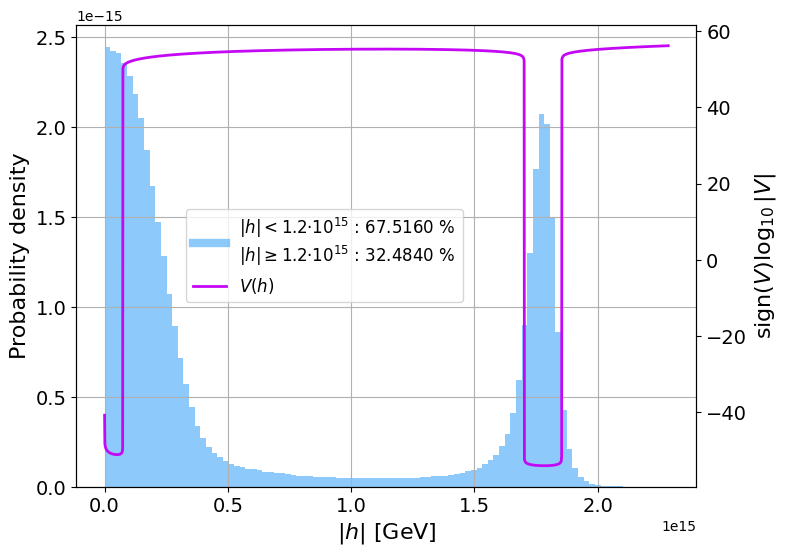

In [45]:
#Plotting an histogram and potential with percentages
nu = 10
Hkin =1.2e12
mtop=171.036
hoL=1e17
g=1
Xi = nu*nu * 2 / 3
fStar = np.sqrt(6 * Xi) * Hkin
if __name__ == "__main__":

    h5_filename = "./escaneo_Hkin/mtop171.036/HKIN1p2e12/field_snapshot_scalar_real.h5"
    dataset_name = "PHI_S_0"  
    index =2
    fileoutname = 0
    limite = 1.2e15

    field_percentage(h5_filename,dataset_name,index,fStar,limite)
    plot_field_histogram_percentages_potential(h5_filename, dataset_name,index,Hkin,nu,hoL,g,mtop,limite,fileoutname)

    
    

Available times in PHI_S_0: ['0.', '1.', '2.', '3.', '4.', '5.', '6.', '7.', '8.', '9.', '10.', '11.', '12.', '13.', '14.', '15.', '16.', '17.', '18.', '19.', '20.', '21.', '22.', '23.', '24.', '25.', '26.', '27.', '28.', '29.', '30.', '31.', '32.', '33.', '34.', '35.', '36.', '37.', '38.', '39.', '40.', '41.', '42.', '43.', '44.', '45.', '46.', '47.', '48.', '49.', '50.', '51.', '52.', '53.', '54.', '55.', '56.', '57.', '58.', '59.', '60.', '61.', '62.', '63.', '64.', '65.', '66.', '67.', '68.', '69.', '70.', '71.', '72.', '73.', '74.', '75.', '76.', '77.', '78.', '79.', '80.', '81.', '82.', '83.', '84.', '85.', '86.', '87.', '88.', '89.', '90.', '91.', '92.', '93.', '94.', '95.', '96.', '97.', '98.', '99.', '100.', '101.', '102.', '103.', '104.', '105.', '106.', '107.', '108.', '109.', '110.', '111.', '112.', '113.', '114.', '115.', '116.', '117.', '118.', '119.', '120.', '121.', '122.', '123.', '124.', '125.', '126.', '127.', '128.', '129.', '130.', '131.', '132.', '133.', '134.', '

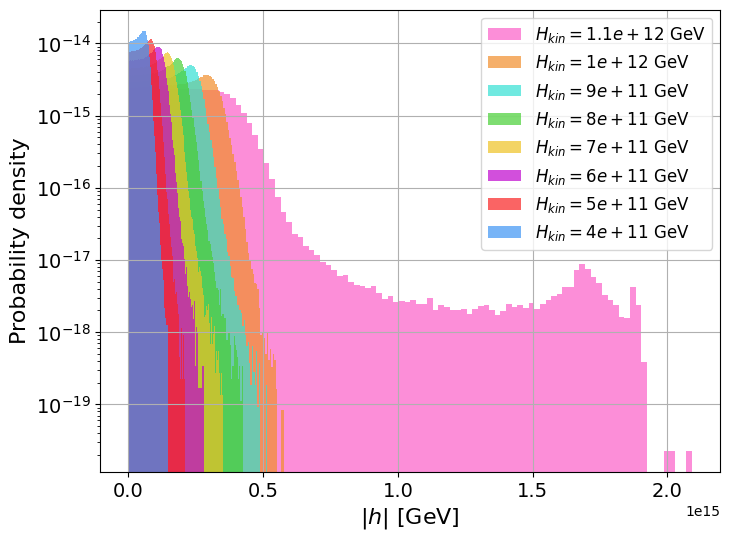

30.0

In [46]:
dataset_name = "PHI_S_0"  
index =30
fileoutname = 0 
h5_filenames = []
colors = [	"#FC5FC8","#F28E2B"	,"#34E1D3","#47CF35","#EEC224","#C004CE","#F92323","#3D95F4"]

hkins2 = [1.1e12]
hkins=[1e12,9e11,8e11,7e11,6e11,5e11,4e11]
for hkin in hkins2:
    h5_filenames.append(f"./escaneo_Hkin/mtop171.036/HKIN{hkin:.1e}/field_snapshot_scalar_real.h5".replace("+", ""))
for hkin in hkins:
    h5_filenames.append(f"./escaneo_Hkin/mtop171.036/HKIN{hkin:.0e}/field_snapshot_scalar_real.h5".replace("+", ""))

plot_field_histogram(h5_filenames, dataset_name,index,hkins,hkins2,nu,colors,fileoutname)
